In [1]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np

Importing fashion image dataset

In [2]:
fashion_mnist=keras.datasets.fashion_mnist
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


Scaling the images to a range of 0 to 1

In [3]:
X_valid,X_train=X_train_full[:5000]/255.0,X_train_full[5000:]/255.0
y_valid,y_train=y_train_full[:5000],y_train_full[5000:]

class_names=["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Creating the model using sequentional API

In [4]:
model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])) #first layer, model Flatten is used to convert an input image to 1D array (it does reshape(-1,1))
model.add(keras.layers.Dense(300,activation="relu"))# dense layer with relu activation function with 300 neurons
model.add(keras.layers.Dense(100,activation="relu"))# another dense layer with 100 neurons
model.add(keras.layers.Dense(10,activation="softmax")) # output layer 10 neurons one per class 

# other approch to building a model
# you can apss a list of layers into the model
# model = keras.models.Sequential([
# keras.layers.Flatten(input_shape=[28, 28]),
# keras.layers.Dense(300, activation="relu"),
# keras.layers.Dense(100, activation="relu"),
# keras.layers.Dense(10, activation="softmax")
# ])


c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Overview of the model

In [5]:
model.summary()
model.layers
hidden1=model.layers[1]
print(hidden1.name)
weights,biases=hidden1.get_weights()
print(weights)
print(weights.shape)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

dense
[[-0.0428264  -0.02170512 -0.05258346 ... -0.03621589 -0.07358178
  -0.04739998]
 [ 0.01937571 -0.03278436  0.02491929 ...  0.07049504  0.01833919
  -0.0468995 ]
 [-0.04466956 -0.06207217  0.00706114 ...  0.05725299 -0.02031625
  -0.07188842]
 ...
 [-0.06183049 -0.04363507 -0.06158273 ... -0.01915466 -0.06100048
   0.05991191]
 [-0.05899257  0.02798469  0.04567698 ... -0.0095752  -0.07381546
  -0.01686437]
 [-0.01411593 -0.01800772  0.03396982 ...  0.04755612  0.01344432
   0.06315269]]
(784, 300)


Compiling the model
spares_caterogory_crossentropy->used in multicategory classification problems with large number of categories where target labels are integers rather than one-hot encoded vectors

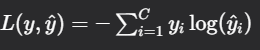

If we had one target label per image we would use categorical_crossentropy instead for exmaple fo one-hot encoded vectors.

sgd -> means we are using stochastic gradient descent optimizer for training the model

In [6]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [7]:
history=model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7570 - loss: 0.7277 - val_accuracy: 0.8244 - val_loss: 0.5180
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8285 - loss: 0.4951 - val_accuracy: 0.8300 - val_loss: 0.4676
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8424 - loss: 0.4483 - val_accuracy: 0.8432 - val_loss: 0.4516
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8523 - loss: 0.4198 - val_accuracy: 0.8606 - val_loss: 0.4022
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8603 - loss: 0.3989 - val_accuracy: 0.8554 - val_loss: 0.4042
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8649 - loss: 0.3823 - val_accuracy: 0.8682 - val_loss: 0.3827
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8692 - loss: 0.3692 - val_accuracy: 0.8754 - val_loss: 0.3617
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8744 - loss: 0.3563 - 

Learning curves for training and validation accuracy

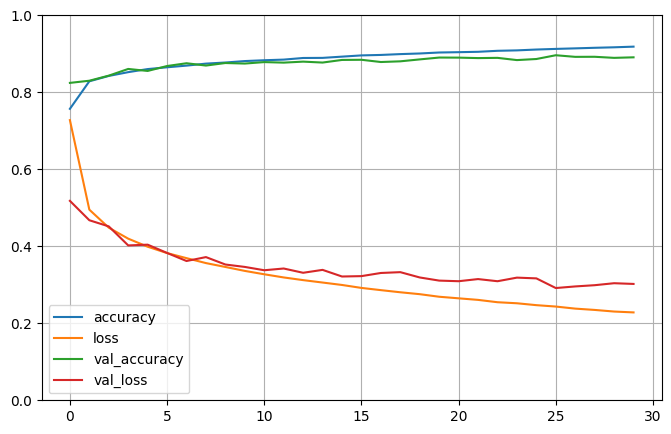

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) # vertical range to [0,1]
plt.show()

In [9]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8602 - loss: 61.5624


[61.56235122680664, 0.8601999878883362]

Predictions on test data

In [10]:
X_new=X_test[:3]
y_proba=model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [11]:
y_pred = y_proba.argmax(axis=1)
y_pred
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

Moving to next project - regression problem and building complex model

In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [13]:
housing=fetch_california_housing()

X_train_full,X_test,y_train_full,y_test=train_test_split(housing.data,housing.target)

X_train,X_valid,y_train,y_valid=train_test_split(X_train_full,y_train_full)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_valid=scaler.fit_transform(X_valid)
X_test=scaler.fit_transform(X_test)
X_new=X_test[:3]


Throught process of building model:
1. Define the type of input data  and shape of the data
2. Creating dense layers with appropriate number of neurons and activation function relu. We call it as a function passing it the input. We tell keras how to connect the layers by passing the output of one layer as input to the next layer.
3. We create a second hidden layer and we past the output of the first layer as input to the second layer.
4. after that we vreate a Concat layer to combine the outputs of the two hidden layers.
5. Finally we create the output layer with a single neuron and no activation function since this is a regression problem.

In [14]:
input_=keras.layers.Input(shape=X_train.shape[1:])
hidden1=keras.layers.Dense(30,activation='relu')(input_)
hidden2=keras.layers.Dense(30,activation='relu')(hidden1)
concat=keras.layers.Concatenate()([input_,hidden2])
output=keras.layers.Dense(1)(concat)
model=keras.Model(inputs=[input_],outputs=[output])

Compiling model

In [15]:
model.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history=model.fit(X_train,y_train,epochs=20,validation_data=(X_valid,y_valid))
model.save("my_first_keras.h5")
mse_test=model.evaluate(X_test,y_test)
y_pred=model.predict(X_new)
# loading the model
# model=keras.models.load_model("my_first_keras.h5")

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6629 - val_loss: 0.8051
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7360 - val_loss: 0.7188
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6392 - val_loss: 0.6672
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5992 - val_loss: 0.6357
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5692 - val_loss: 0.6106
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5469 - val_loss: 0.5949
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5266 - val_loss: 0.5753
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5123 - val_loss: 0.5750
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4979 - val_loss: 0.5530
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4900 - val_loss: 0.5453
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4789 - val_loss: 0.5393
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 0.4770
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Us cases:
- for example locating and identifying objects in an image ( regression + classification)
- multiuotput model where we have multiple outputs from the model for example predicting both the price of a house and the number of bedrooms based on various input features.

Exampel of adding extra output to the model:

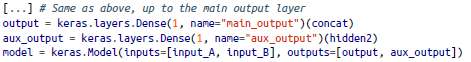


Using TensorBoard to visualize the model training process

In [16]:
import os

root_logdir=os.path.join(os.curdir,"my_logs")

def get_run_logdir():
    import time
    run_id=time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir,run_id)

run_logdir=get_run_logdir()

In [17]:
model.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=1e-3))
tensorboard_cb=keras.callbacks.TensorBoard(run_logdir)
history=model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid),callbacks=[tensorboard_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4243 - val_loss: 0.4904
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4210 - val_loss: 0.4886
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4173 - val_loss: 0.4861
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4143 - val_loss: 0.4824
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4111 - val_loss: 0.4791
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4084 - val_loss: 0.4774
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4055 - val_loss: 0.4753
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4027 - val_loss: 0.4720
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4000 - val_loss: 0.4745
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3981 - val_loss: 0.4681
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3958 - val_loss: 0.4659
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

After running the script to look at the data that are saved in file logs/fit you can run the following command in terminal to launch TensorBoard server:

```bash
tensorboard --logdir=./my_logs --port=6006
```

In [18]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        data = (np.random.randn(100) + 2) * step / 100 # some random data
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        images = np.random.rand(2, 32, 32, 3) # random 32×32 RGB images
        tf.summary.image("my_images", images * step / 1000, step=step)
        texts = ["The step is " + str(step), "Its square is " + str(step**2)]
        tf.summary.text("my_text", texts, step=step)
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

Fine tuning neural networks hyperparameters using Keras Tuner

In [19]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=1e-3, input_shape=[8]):
    model=keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons,activation='relu'))
    model.add(keras.layers.Dense(1))
    optimizer=keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse",optimizer=optimizer)
    return model

In [20]:
from scikeras.wrappers import KerasRegressor
keras_reg = KerasRegressor(model=build_model,n_hidden=1, n_neurons=30, learning_rate=1e-3)#wrapper around Keras model built by build_model and we can use 
# it as na object now

keras_reg.fit(X_train,y_train,epochs=100,validation_data=(X_valid,y_valid), 
              callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test=keras_reg.score(X_test,y_test)
y_pred=keras_reg.predict(X_new)

Epoch 1/100
  1/363 ━━━━━━━━━━━━━━━━━━━━ 51s 143ms/step - loss: 2.6489

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8486 - val_loss: 1.1325
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8824 - val_loss: 0.8224
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7304 - val_loss: 0.7602
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6801 - val_loss: 0.7160
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6486 - val_loss: 0.6851
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6182 - val_loss: 0.6590
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5932 - val_loss: 0.6366
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5711 - val_loss: 0.6146
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5536 - val_loss: 0.6003
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5357 - val_loss: 0.5858
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5224 - val_loss: 0.5723
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [21]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

param_distribs={
    "n_hidden":[0,1,2,3],
    "n_neurons":np.arange(1,100),
    "learning_rate":reciprocal(3e-4,3e-2),
}

rnd_search_CV=RandomizedSearchCV(keras_reg,param_distribs, n_iter=10,cv=3)
rnd_search_CV.fit(X_train,y_train,epochs=100,validation_data=(X_valid,y_valid),
                  callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
  1/242 ━━━━━━━━━━━━━━━━━━━━ 36s 153ms/step - loss: 5.3609

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3076 - val_loss: 0.8415
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7246 - val_loss: 0.7116
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6437 - val_loss: 0.6505
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5913 - val_loss: 0.6180
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5527 - val_loss: 0.5905
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5256 - val_loss: 0.5774
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5051 - val_loss: 0.5715
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4896 - val_loss: 0.5687
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4781 - val_loss: 0.5681
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4682 - val_loss: 0.5644
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4603 - val_loss: 0.5636
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2893 - val_loss: 0.8931
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7569 - val_loss: 0.8888
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9392 - val_loss: 0.8807
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8306 - val_loss: 0.6066
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5508 - val_loss: 0.5866
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5094 - val_loss: 0.5676
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4909 - val_loss: 0.5496
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4761 - val_loss: 0.5342
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4646 - val_loss: 0.5260
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4546 - val_loss: 0.5156
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4471 - val_loss: 0.5097
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 492, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mateu\Desktop\python\ML_pract

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9699 - val_loss: 0.5755
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.4498 - val_loss: 0.4915
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4256 - val_loss: 2.8894
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5085 - val_loss: 2.8936
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan
Epoch 13/100


c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 492, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\mateu\Desktop\python\ML_practice\1\.venv\Lib\site-packages\scikeras\wrappers.py", line 1127, in score
    return self.scorer(y, y_pred, sample_weight=sample_weight, **score_args)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mateu\Desktop\python\ML_pract

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7908 - val_loss: 0.7529
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5679 - val_loss: 0.5337
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4203 - val_loss: 0.4692
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3914 - val_loss: 0.4593
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3759 - val_loss: 0.4420
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3689 - val_loss: 0.4473
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3633 - val_loss: 0.4354
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3583 - val_loss: 0.4288
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3551 - val_loss: 0.4322
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3516 - val_loss: 0.4186
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3487 - val_loss: 0.4291
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

,estimator,KerasRegresso...g_rate=0.001 )
,param_distributions,"{'learning_rate': <scipy.stats....0022602569E80>, 'n_hidden': [0, 1, ...], 'n_neurons': array([ 1, 2..., 97, 98, 99])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [23]:
print(rnd_search_CV.best_params_)
print(rnd_search_CV.best_score_)
model=rnd_search_CV.best_estimator_.model

{'learning_rate': np.float64(0.009073195984639), 'n_hidden': 2, 'n_neurons': np.int64(30)}
0.7775237937544048
